# Analisi Retailer E-commerce (Azienda Z)

## 1. Web Scraping Dinamico e Multi-Brand
Per estrarre i dati da questo e-commerce (Azienda Z) adottiamo una strategia avanzata. Poiché il sito carica i contenuti dinamicamente, utilizziamo `undetected_chromedriver` (Selenium) accoppiato a uno *smooth scrolling* simulato per forzare il caricamento di tutte le *product card* ed evitare blocchi anti-bot.

In questa fase:
* Filtriamo e catturiamo solo i prodotti appartenenti ai nostri brand target (C, G e NG) tramite una mappatura basata su variabili d'ambiente.
* Estraiamo la stringa descrittiva completa ("Modelli").
* Recuperiamo il "Prezzo Corrente" e il "Prezzo Mediano" (che funge da prezzo di listino originale).

In [10]:
from Library import *
load_dotenv()

URL_Z = os.getenv("URL_Z")

# Parse the mapping from the .env file into a dictionary
env_mapping_str = os.getenv("TARGET_BRANDS_MAPPING")
brand_map = {}
if env_mapping_str:
    for coppia in env_mapping_str.split(","):
        chiave, valore = coppia.split(":")
        brand_map[chiave.strip().lower()] = valore.strip()

target_brands = list(brand_map.keys())
    
lista_scarpe = []

options = uc.ChromeOptions()
options.add_argument("--lang=it-IT")
options.add_argument("--window-size=1920,1080")

driver = uc.Chrome(options=options)

for page in range(1, 11):
    print(f"\nScraping pagina {page}...")
    driver.get(f"{URL_Z}?p={page}")

    #rendiamolo la richiesta più umana possibile
    time.sleep(random.uniform(3.5, 5.5))
    
    try:
        WebDriverWait(driver, 15).until(
            EC.presence_of_element_located((By.TAG_NAME, "article"))
        )
    except Exception as e:
        print(f"Timeout sulla pagina {page}")
        break
        
    # SMOOTH SCROLLING UMANO
    ultima_parte = driver.execute_script("return document.body.scrollHeight")
    for scroll_step in range(0, ultima_parte, 600):
        driver.execute_script(f"window.scrollTo(0, {scroll_step});")
        time.sleep(random.uniform(0.3, 0.6))
    
    # randomiziamo i momenti per evitare blocchi
    time.sleep(random.uniform(1.5, 2.5))
    
    soup = bs(driver.page_source, "html.parser")
    cards = soup.find_all("article")
    
    print(f"Trovati {len(cards)} items sulla pagina {page}. Estraggo i dati...")
    
    for card in cards:
        testo = list(card.stripped_strings)
        if not testo:
            continue
            
        parole_ignorate = [
            "promo", "heart_outlined", "novità", "sostenibilità", 
            "premium", "esclusiva", "planetnicolaas", "segui", 
            "sponsored", "sponsorizzato", "plus", "sostenibile",
            "consigliato", "taglie"
        ]
        
        testo_pulito = [t for t in testo if t.lower() not in parole_ignorate]
        
        if not testo_pulito:
            continue
            
        brand = "N/A"
        modelli = "N/A"
        
        # Estraiamo solo i brand che mi interessano
        for i, parole in enumerate(testo_pulito):
            for target in target_brands:
                if target in parole.lower():
                    brand = brand_map[target]
                    if i + 1 < len(testo_pulito):
                        modelli = testo_pulito[i+1]
                    break
            if brand != "N/A":
                break
                
        if brand == "N/A":
            continue
            
        prezzo_corrente = "N/A"
        prezzo_mediano = "N/A"
        
        for i, parole in enumerate(testo_pulito):
            if "€" in parole and prezzo_corrente == "N/A":
                prezzo_corrente = parole
            if "Prezzo mediano" in parole and i + 1 < len(testo_pulito):
                prezzo_mediano = testo_pulito[i + 1]
                
        lista_scarpe.append({
            "Brand": brand,
            "Modelli": modelli,
            "Prezzo Corrente": prezzo_corrente,
            "Prezzo Mediano": prezzo_mediano
        })

driver.quit()

print(f"\nScraping completato. Estratti: {len(lista_scarpe)} prodotti")
df = pd.DataFrame(lista_scarpe)
print(df)


Scraping pagina 1...
Trovati 102 items sulla pagina 1. Estraggo i dati...

Scraping pagina 2...
Trovati 100 items sulla pagina 2. Estraggo i dati...

Scraping pagina 3...
Trovati 101 items sulla pagina 3. Estraggo i dati...

Scraping pagina 4...
Trovati 99 items sulla pagina 4. Estraggo i dati...

Scraping pagina 5...
Trovati 99 items sulla pagina 5. Estraggo i dati...

Scraping pagina 6...
Trovati 100 items sulla pagina 6. Estraggo i dati...

Scraping pagina 7...
Trovati 100 items sulla pagina 7. Estraggo i dati...

Scraping pagina 8...
Trovati 100 items sulla pagina 8. Estraggo i dati...

Scraping pagina 9...
Trovati 99 items sulla pagina 9. Estraggo i dati...

Scraping pagina 10...
Trovati 51 items sulla pagina 10. Estraggo i dati...

Scraping completato. Estratti: 777 prodotti
         Brand                                    Modelli Prezzo Corrente  \
0    Azienda G          SPHERICA - Sneakers basse - black         89,99 €   
1    Azienda G  SPHERICA ACTIF X4 - Sneakers basse - 

In [11]:
df.to_csv("Z da pulire.csv",index = False)

## 2. Data Cleaning: Parsing di Prezzi e Attributi
La stringa descrittiva estratta contiene molteplici informazioni condensate. Per strutturare il dato:
1. **Split degli Attributi:** Dividiamo la colonna "Modelli" usando il separatore testuale ` - `, ricavando tre nuove feature: **Scarpe** (Nome del modello), **Categoria** e **Dettaglio/Colore**.
2. **Formattazione Prezzi:** Rimuoviamo il simbolo dell'Euro, gestiamo gli spazi non standard (`\xa0`) e convertiamo i prezzi in valori numerici `float`.
3. **Logica Promozionale:** Calcoliamo il `Prezzo reale` (Listino) colmando i vuoti con il prezzo corrente, isoliamo il `Prezzo scontato` e creiamo la variabile booleana `In sconto`.

In [12]:
# Split della colonna 'Modelli' in 3 parti perchè abbiamo preso tutto il contenuto in fase di scraping
colonne_splittate = df['Modelli'].str.split(' - ', n=2, expand=True)

df['Scarpe'] = colonne_splittate[0] if 0 in colonne_splittate.columns else df['Modelli']
df['Categoria'] = colonne_splittate[1] if 1 in colonne_splittate.columns else "Non specificata"
df['Dettaglio/Colore'] = colonne_splittate[2] if 2 in colonne_splittate.columns else "Non specificato"

df['Prezzo Corrente'] = (df['Prezzo Corrente'].astype(str).str.replace('€', '', regex=False).str.replace('\xa0', '', regex=False).str.strip().str.replace(',', '.', regex=False))
df['Prezzo Corrente'] = pd.to_numeric(df['Prezzo Corrente'], errors='coerce')

df['Prezzo Mediano'] = (df['Prezzo Mediano'].astype(str).str.replace('€', '', regex=False).str.replace('\xa0', '', regex=False).str.strip().str.replace(',', '.', regex=False))
df['Prezzo Mediano'] = pd.to_numeric(df['Prezzo Mediano'], errors='coerce')

df['Prezzo reale'] = df['Prezzo Mediano'].fillna(df['Prezzo Corrente'])
df['Prezzo scontato'] = df['Prezzo Corrente']

df['In sconto'] = df['Prezzo reale'] > df['Prezzo scontato']

df = df.drop(columns=['Modelli', 'Prezzo Corrente', 'Prezzo Mediano'])

Finale = ['Brand', 'Scarpe', 'Categoria', 'Prezzo reale', 'Prezzo scontato', 'In sconto', 'Dettaglio/Colore']
df = df[Finale]

print(df.head(10))

df.to_csv("Azienda Z.csv", index=False)
print("\nDataset salvato con successo.")

       Brand             Scarpe           Categoria  Prezzo reale  \
0  Azienda G           SPHERICA      Sneakers basse         99.99   
1  Azienda G  SPHERICA ACTIF X4      Sneakers basse         89.99   
2  Azienda C              SWIFT      Sneakers basse        119.99   
3  Azienda G        U BALTMOORE      Sneakers basse         99.90   
4  Azienda G         U SPHERICA      Sneakers basse        109.00   
5  Azienda C            ATTICUS  Stringate eleganti         99.99   
6  Azienda G    U SPHERICA PLUS      Sneakers basse        109.99   
7  Azienda G        UOMO SYMBOL  Stringate sportive        109.99   
8  Azienda G     Sneakers basse                navy        124.99   
9  Azienda C        CORSLEY BAR  Scarpe senza lacci         89.99   

   Prezzo scontato  In sconto Dettaglio/Colore  
0            89.99       True            black  
1            89.99      False             navy  
2           101.99       True            black  
3            99.90      False            jea

In [13]:
from Library import *
df = pd.read_csv("Azienda Z.csv")

## 3. Data Quality: Risoluzione Anomalie e RegEx
Durante lo split delle stringhe, alcuni prodotti presentavano pattern anomali (Nome e Categoria invertiti). 
Implementiamo un controllo di qualità incrociato con un set di categorie valide (`CAT_VALIDE`) per "scambiare" le celle invertite e ripristinare la coerenza dei dati.

Inoltre, utilizziamo le *Espressioni Regolari (RegEx)* per "ripulire" i nomi dei modelli da prefissi o suffissi inseriti dal retailer (es. "UOMO ", codici numerici, "VAR") che impedirebbero la corretta identificazione della scarpa.

In [14]:
# Categorie valide attese nel campo Categoria
CAT_VALIDE = {
    "sneakers basse", "sneakers alte", "scarpe senza lacci", "scarpe skate",
    "stringate sportive", "stringate eleganti", "stringate",
    "mocassini eleganti", "mocassini", "scarpe da barca",
    "sandali", "sandali da trekking",
    "stivaletti", "stivaletti stringati", "ciabattine"
}

# Fix righe con split sbagliato: Scarpe e Categoria invertiti
mask_swap = (
    ~df["Categoria"].str.strip().str.lower().isin(CAT_VALIDE) &
     df["Scarpe"].str.strip().str.lower().isin(CAT_VALIDE)
)
print(f"Righe con split sbagliato corrette: {mask_swap.sum()}")
df.loc[mask_swap, ["Scarpe", "Categoria"]] = \
    df.loc[mask_swap, ["Categoria", "Scarpe"]].values

# Pulizia nomi modello: rimuovi prefissi ridondanti
df["Scarpe"] = df["Scarpe"].str.replace(r'^U\s+', '', regex=True)
df["Scarpe"] = df["Scarpe"].str.replace(r'^UOMO\s+', '', regex=True)
df["Scarpe"] = df["Scarpe"].str.replace(r'\s+C\d{4}.*$', '', regex=True)
df["Scarpe"] = df["Scarpe"].str.replace(r'\s+VAR$', '', regex=True)
df["Scarpe"] = df["Scarpe"].str.strip().str.title()

# Rimuovi righe con categoria non riconoscibile
mask_valid = df["Categoria"].str.strip().str.lower().isin(CAT_VALIDE)
print(f"Righe con categoria non valida rimosse: {(~mask_valid).sum()}")
df = df[mask_valid].copy()

print(f"Righe valide totali: {len(df)}")
print(f"\nDistribuzione brand:\n{df['Brand'].value_counts()}")

Righe con split sbagliato corrette: 185
Righe con categoria non valida rimosse: 38
Righe valide totali: 739

Distribuzione brand:
Brand
Azienda G     477
Azienda C     204
Azienda NG     58
Name: count, dtype: int64


## 4. Mappatura Tassonomica
Applichiamo la nostra architettura standard per categorizzare l'assortimento. Associamo le categorie specifiche del retailer Z alle nostre **Macro** e **Micro-categorie**. Essendo un portale multibrand, avere un'unica nomenclatura ci permetterà di confrontare mele con mele quando incroceremo i dati di C, G e NG.

In [15]:
MACRO_MICRO_Z = {
    "sneakers basse":("Sneakers","Sneakers basse"),
    "sneakers alte":("Sneakers","Sneakers alte"),
    "scarpe senza lacci":("Sneakers","Sneakers basse"),
    "scarpe skate":("Sneakers","Sneakers basse"),
    "stringate sportive":("Sneakers","Sneakers basse"),
    "stringate eleganti":("Scarpe eleganti","Stringate / Derby"),
    "stringate":("Scarpe eleganti","Stringate / Derby"),
    "mocassini eleganti":("Mocassini","Mocassini"),
    "mocassini":("Mocassini","Mocassini"),
    "scarpe da barca":("Mocassini","Boat shoes"),
    "sandali":("Sandali","Sandali aperti"),
    "sandali da trekking":("Sandali","Sandali sportivi"),
    "stivaletti":("Stivali & Stivaletti", "Stivaletti"),
    "stivaletti stringati":("Stivali & Stivaletti", "Stivaletti"),
    "ciabattine":("Ciabatte & Pantofole", "Ciabatte"),
}

mapped = df["Categoria"].str.strip().str.lower().apply(
    lambda x: MACRO_MICRO_Z.get(x, ("Altro", "Altro"))
)
df["Macro_categoria"] = mapped.apply(lambda x: x[0])
df["Micro_categoria"]  = mapped.apply(lambda x: x[1])

non_mappate = df[df["Macro_categoria"] == "Altro"]["Categoria"].unique()
print(f"Categorie non mappate: {non_mappate if len(non_mappate) else 'Nessuna'}")
print(f"\nDistribuzione Macro-categoria:\n{df['Macro_categoria'].value_counts()}")

Categorie non mappate: Nessuna

Distribuzione Macro-categoria:
Macro_categoria
Sneakers                476
Stivali & Stivaletti     98
Scarpe eleganti          61
Mocassini                48
Sandali                  35
Ciabatte & Pantofole     21
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA) Multibrand

### 5.1 Benchmarking delle Politiche di Pricing
Avendo i tre brand sullo stesso portale, possiamo confrontare direttamente il loro posizionamento e le logiche di sconto applicate dall'e-commerce. Calcoliamo i prezzi medi (reali e scontati) e li visualizziamo tramite un grafico a barre raggruppato, per misurare l'aggressività promozionale del retailer sui diversi marchi.

--- Prezzi su Z-E-commerce per brand ---
           Prezzo reale                Prezzo scontato              
                   mean    min     max            mean    min    max
Brand                                                               
Azienda C        123.50  47.40  230.00          115.00  47.40  230.0
Azienda G        114.68  62.90  313.42          110.14  59.90  275.0
Azienda NG       157.91  94.99  209.90          148.55  94.99  209.9


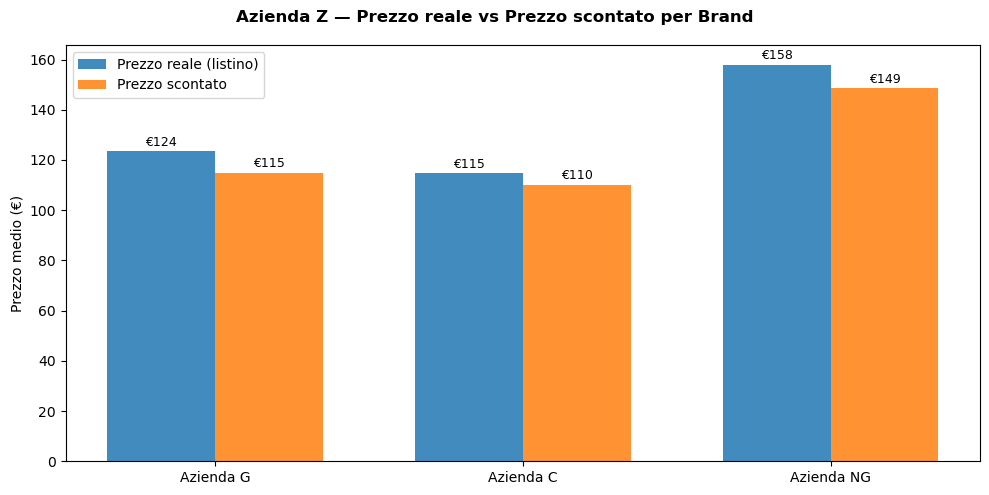

In [16]:
print("--- Prezzi su Z-E-commerce per brand ---")
print(df.groupby("Brand")[["Prezzo reale", "Prezzo scontato"]].agg(
    ["mean", "min", "max"]
).round(2))

# Confronto prezzo reale vs prezzo scontato
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Azienda Z — Prezzo reale vs Prezzo scontato per Brand", fontweight="bold")

brands= df["Brand"].unique()
prezzi_reali= df.groupby("Brand")["Prezzo reale"].mean()
prezzi_scontati = df.groupby("Brand")["Prezzo scontato"].mean()

x= range(len(brands))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], prezzi_reali,    width,
               label="Prezzo reale (listino)", alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], prezzi_scontati, width,
               label="Prezzo scontato", alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(brands)
ax.set_ylabel("Prezzo medio (€)")
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'€{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'€{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 5.2 Analisi della Profondità di Colore
Una leva fondamentale per il retail online è la profondità cromatica. Contiamo il numero di colori distinti per ogni brand e identifichiamo la *Top 5* delle varianti più popolari. Infine, incrociamo questa ampiezza di scelta cromatica con le Macro-categorie per scoprire dove ogni marchio investe maggiormente sulla varietà.

--- N° colori distinti per brand ---
Brand
C      67
G     119
NG     10
Name: Dettaglio/Colore, dtype: int64

--- Top 5 colori per brand ---

G:
Dettaglio/Colore
black        64
navy         51
dove grey    14
coffee       14
dark blue    12

C:
Dettaglio/Colore
black    29
navy     12
brown    11
white     6
cola      6

NG:
Dettaglio/Colore
blu        3
marrone    1
yogurt     1
bianco     1
beige      1


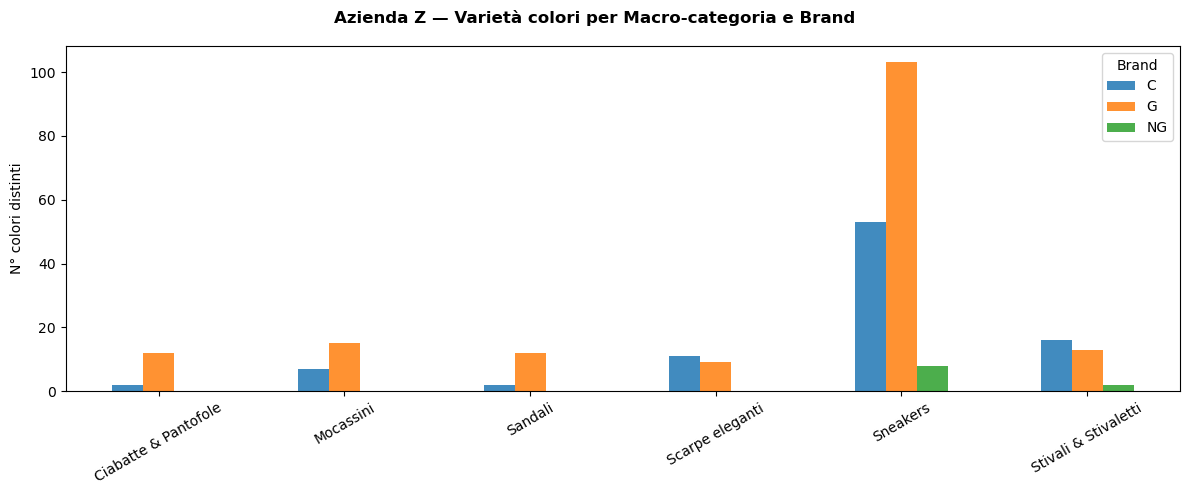

In [20]:
print("--- N° colori distinti per brand ---")
print(df.groupby("Brand")["Dettaglio/Colore"].nunique())

print("\n--- Top 5 colori per brand ---")
for brand in df["Brand"].unique():
    print(f"\n{brand}:")
    print(df[df["Brand"] == brand]["Dettaglio/Colore"].value_counts().head(5).to_string())

# Varietà colori per macro-categoria e brand
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Azienda Z — Varietà colori per Macro-categoria e Brand", fontweight="bold")

colori_cat = df.groupby(["Brand", "Macro_categoria"])["Dettaglio/Colore"].nunique().unstack(0)
colori_cat.plot(kind="bar", ax=ax, alpha=0.85)
ax.set_xlabel("")
ax.set_ylabel("N° colori distinti")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 6. Export Finale
Ultimi ritocchi estetici alla colonna Brand e salvataggio del dataset finale (`Azienda_Z_clean.csv`). Questo documento rappresenta una fonte di dati "terza" (il Retailer) potentissima per validare le strategie *Direct-to-Consumer* dei tre brand ricavate in precedenza dai loro siti ufficiali.

In [18]:
df["Brand"] = df["Brand"].str.replace("Azienda ", "", regex=False)

df.to_csv("Azienda_Z_clean.csv", index=False)
print("Azienda_Z_clean.csv salvato")
print(f"Colonne: {list(df.columns)}")
print(f"Righe:{len(df)}")

Azienda_Z_clean.csv salvato
Colonne: ['Brand', 'Scarpe', 'Categoria', 'Prezzo reale', 'Prezzo scontato', 'In sconto', 'Dettaglio/Colore', 'Macro_categoria', 'Micro_categoria']
Righe:739


In [19]:
df

,Brand,Scarpe,Categoria,Prezzo reale,Prezzo scontato,In sconto,Dettaglio/Colore,Macro_categoria,Micro_categoria
0,G,Spherica,Sneakers basse,99.99,89.99,True,black,Sneakers,Sneakers basse
1,G,Spherica Actif X4,Sneakers basse,89.99,89.99,False,navy,Sneakers,Sneakers basse
2,C,Swift,Sneakers basse,119.99,101.99,True,black,Sneakers,Sneakers basse
3,G,Baltmoore,Sneakers basse,99.90,99.90,False,jeans,Sneakers,Sneakers basse
4,G,Spherica,Sneakers basse,109.00,87.00,True,dark blue,Sneakers,Sneakers basse
...,...,...,...,...,...,...,...,...,...
772,G,Symbol,Stringate sportive,109.99,109.99,False,black,Sneakers,Sneakers basse
773,C,Clarkdale Easy,Stivaletti,159.99,159.99,False,black,Stivali & Stivaletti,Stivaletti
774,C,Craftarlo Limit,Stringate,119.99,119.99,False,tan,Scarpe eleganti,Stringate / Derby
775,C,Wallabeegtx,Stringate sportive,229.99,229.99,False,black,Sneakers,Sneakers basse


## 7. Conclusioni e Key Takeaways (Retailer Z)

L'analisi dell'offerta dei tre brand target (C, G, NG) sul portale del Retailer Z ci fornisce una preziosa prospettiva "esterna" sulle dinamiche competitive:

* **Volumi e Presenza:** L'Azienda G domina lo scaffale digitale di questo retailer con la fetta maggioritaria dei prodotti esposti (477 su 739), seguita dall'Azienda C (204). L'Azienda NG mantiene una presenza di nicchia (58), coerente con il suo probabile approccio più esclusivo.
* **Posizionamento di Prezzo Confermati:** I prezzi medi rispecchiano le strategie viste sui siti ufficiali. L'Azienda NG è il brand premium (circa €158 di listino), l'Azienda C si posiziona nel *mid-high* (circa €123), mentre l'Azienda G ha il prezzo medio più accessibile (circa €114).
* **Profondità e Varietà Cromatica:** C'è una fortissima correlazione tra i volumi e la varietà dei colori. L'Azienda G offre ben 119 colori/varianti distinte, facendo della varietà una sua arma chiave. Il nero ("black") e il "navy" sono di gran lunga i colori cardine per i brand G e C, indicando una forte preferenza del retailer per le tinte "sicure" e commerciali.
* **Egemonia Sneakers:** Indipendentemente dal brand, la macro-categoria "Sneakers" cannibalizza le vendite sul portale (476 prodotti su 739 totali). Stivali e Mocassini rappresentano il secondo e terzo gradino, ma a grande distanza.